In [2]:
#pip install bayesian-optimization

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bayes_opt import BayesianOptimization
from sklearn.preprocessing import label_binarize


import warnings, json, math, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.stats import norm

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, f1_score, classification_report
)
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner


In [24]:
df = pd.read_csv('clean_df (1).csv')
df.shape

(2927, 117)

<Axes: xlabel='SalePrice', ylabel='Count'>

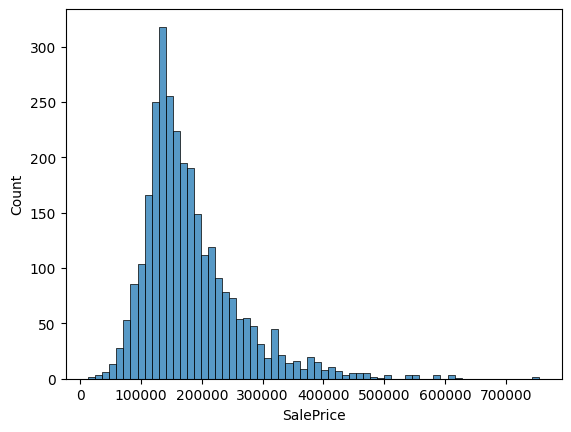

In [25]:
sns.histplot(df['SalePrice'])

Method of grouping one where the goal is for the number of houses per group to fall on a normal distribution

In [26]:
# Desired relative frequencies for 5 intervals
probs = np.array([0.05, 0.15, 0.35, 0.65, 0.85, 0.95])  # cumulative probs
#  → 5%, 10%, 20%, 30%, 20%, 10%, 5%

# Compute actual price cut points at those quantiles
boundaries = df['SalePrice'].quantile(probs).tolist()
boundaries = [df['SalePrice'].min()] + boundaries + [df['SalePrice'].max()]

# Create labels
labels = [f'Interval_{i+1}' for i in range(len(boundaries) - 1)]

# Cut into bins
df['SalePrice_NormalDist_Group'] = pd.cut(df['SalePrice'], bins=boundaries, labels=labels, include_lowest=True)

# Count per bin
counts = df['SalePrice_NormalDist_Group'].value_counts().sort_index()

print("\nReadable interval summary:")
for i in range(len(boundaries) - 1):
    low = int(boundaries[i])
    high = int(boundaries[i + 1])
    label = labels[i]
    count = counts.iloc[i]
    print(f"{label}: {low:,} – {high:,}  ({count} houses)")



Readable interval summary:
Interval_1: 12,789 – 87,515  (147 houses)
Interval_2: 87,515 – 115,359  (292 houses)
Interval_3: 115,359 – 140,000  (589 houses)
Interval_4: 140,000 – 187,090  (874 houses)
Interval_5: 187,090 – 252,000  (590 houses)
Interval_6: 252,000 – 335,000  (291 houses)
Interval_7: 335,000 – 755,000  (144 houses)


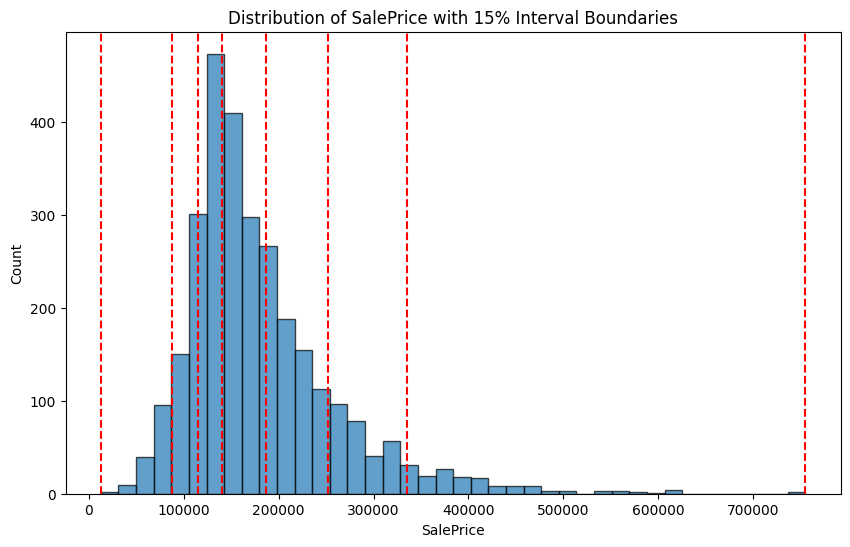

In [27]:
# Plot histogram with interval boundaries
plt.figure(figsize=(10, 6))
plt.hist(df['SalePrice'], bins=40, edgecolor='black', alpha=0.7)
for boundary in boundaries:
    plt.axvline(boundary, color='red', linestyle='--')
plt.title("Distribution of SalePrice with 15% Interval Boundaries")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

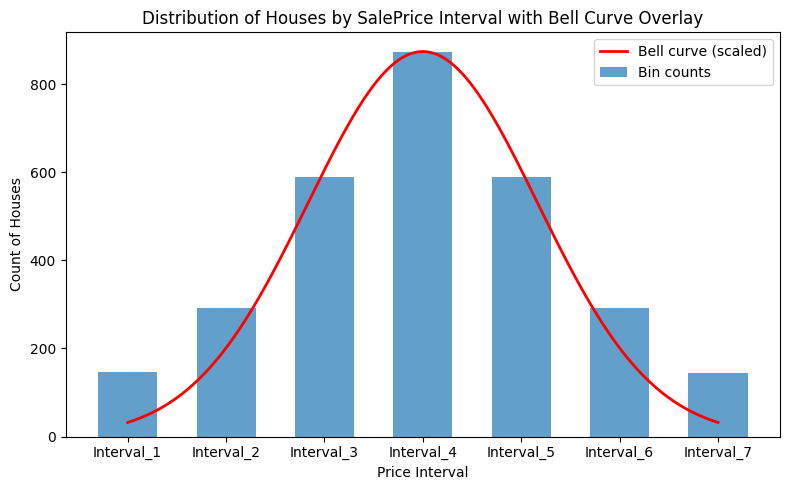

In [28]:
labels = [f'Interval_{i+1}' for i in range(len(boundaries)-1)]
df['SalePrice_NormalDist_Group'] = pd.cut(df['SalePrice'], bins=boundaries, labels=labels, include_lowest=True)

counts = df['SalePrice_NormalDist_Group'].value_counts().sort_index()
x = np.arange(len(counts))  # 0,1,2,3,4 for plotting positions

plt.figure(figsize=(8,5))
plt.bar(x, counts.values, width=0.6, alpha=0.7, label='Bin counts')
plt.xticks(x, counts.index)

x_smooth = np.linspace(x.min(), x.max(), 200)

mu = x.mean()
sigma = len(counts) / 6  # rough spread so curve spans over bins
pdf = norm.pdf(x_smooth, mu, sigma)

pdf_scaled = pdf / pdf.max() * counts.max()
plt.plot(x_smooth, pdf_scaled, color='red', linewidth=2, label='Bell curve (scaled)')

plt.title("Distribution of Houses by SalePrice Interval with Bell Curve Overlay")
plt.xlabel("Price Interval")
plt.ylabel("Count of Houses")
plt.legend()
plt.tight_layout()
plt.show()


Second approach where the intervals are defined by a percent increase from the lower to the upper bound and also a rule that each group must contain at least 100 members.

In [30]:
growth_rate = 0.11         # increase next interval width by 15%
first_interval_pct = 0.05  # first interval = 10% of max price
min_members = 90           # minimum houses per interval

min_price = df['SalePrice'].min()
max_price = df['SalePrice'].max()

intervals = [min_price]
interval_width = max_price * first_interval_pct
current_boundary = min_price + interval_width

def count_in_range(low, high):
    return ((df['SalePrice'] >= low) & (df['SalePrice'] < high)).sum()

while current_boundary < max_price:
    count = count_in_range(intervals[-1], current_boundary)

    while count < min_members and current_boundary < max_price:
        interval_width *= (1 + growth_rate)  # make interval wider
        current_boundary = min(current_boundary + interval_width, max_price)
        count = count_in_range(intervals[-1], current_boundary)
    
    intervals.append(min(current_boundary, max_price))

intervals = sorted(list(set(intervals)))

labels = [f'Interval_{i+1}' for i in range(len(intervals) - 1)]
df['SalePrice_Percent_Group'] = pd.cut(df['SalePrice'], bins=intervals, labels=labels, include_lowest=True)

counts = df['SalePrice_Percent_Group'].value_counts().sort_index()

print("\nReadable interval summary:")
for i in range(len(intervals) - 1):
    low = int(intervals[i])
    high = int(intervals[i + 1])
    label = labels[i]
    count = counts.iloc[i]
    print(f"{label}: {low:,} – {high:,}  ({count} houses)")

print("\nTotal houses:", counts.sum())
print("Total intervals:", len(intervals) - 1)



Readable interval summary:
Interval_1: 12,789 – 92,441  (180 houses)
Interval_2: 92,441 – 138,953  (783 houses)
Interval_3: 138,953 – 190,581  (998 houses)
Interval_4: 190,581 – 247,888  (495 houses)
Interval_5: 247,888 – 311,499  (261 houses)
Interval_6: 311,499 – 382,107  (128 houses)
Interval_7: 382,107 – 755,000  (82 houses)

Total houses: 2927
Total intervals: 7


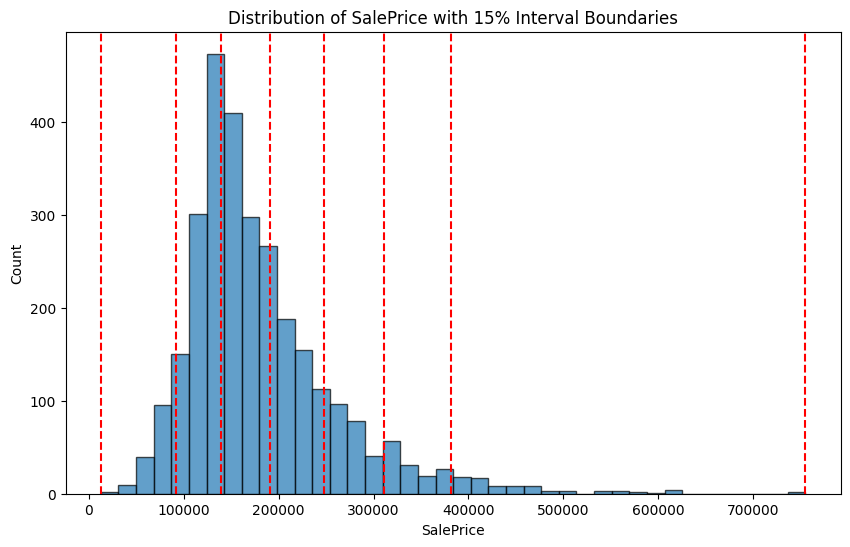

In [31]:
# Plot histogram with interval boundaries
plt.figure(figsize=(10, 6))
plt.hist(df['SalePrice'], bins=40, edgecolor='black', alpha=0.7)
for boundary in intervals:
    plt.axvline(boundary, color='red', linestyle='--')
plt.title("Distribution of SalePrice with 15% Interval Boundaries")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

In [11]:
df.dtypes.value_counts()

int64       62
bool        38
float64     17
category     2
Name: count, dtype: int64

In [12]:
print(df['SalePrice_Percent_Group'].value_counts())
print(df['SalePrice_NormalDist_Group'].value_counts())

SalePrice_Percent_Group
Interval_2    1550
Interval_3     896
Interval_4     254
Interval_1     153
Interval_5      74
Name: count, dtype: int64
SalePrice_NormalDist_Group
Interval_3    1162
Interval_2     593
Interval_4     584
Interval_1     295
Interval_5     293
Name: count, dtype: int64


In [13]:
# Choose your target column
TARGET_COL = "SalePrice_NormalDist_Group"   # or "SalePrice_Percent_Group"
df.drop(columns=['SalePrice'], inplace=True)
df.drop(columns=['SalePrice_Percent_Group'], inplace=True)
#df.drop(subset=['SalePrice_NormalDist_Group'], inplace=True)  # Comment the above line and uncomment this to switch target


assert TARGET_COL in df.columns, f"Target column {TARGET_COL} not in df!"

# Convert categorical target to numeric labels
y = df[TARGET_COL]
if hasattr(y, "cat"):
    y = y.cat.codes
else:
    y = y.astype("category").cat.codes

# Feature matrix (all numeric columns except target)
X = df.drop(columns=[TARGET_COL])

# Verify all are numeric
#assert all(np.issubdtype(dtype, np.number) for dtype in X.dtypes), "All features must be numeric!"

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

n_classes = len(np.unique(y))
print(f"Training samples: {len(X_train)}, Validation: {len(X_valid)}, Classes: {n_classes}")


Training samples: 2634, Validation: 293, Classes: 5


In [14]:
def build_model(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-2, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "tree_method": "hist",
        "objective": "multi:softprob",
        "num_class": n_classes,
        "eval_metric": "mlogloss",
        "random_state": 42,
        "n_jobs": -1,
    }
    return XGBClassifier(**params)

In [15]:
def get_sample_weights(y_vec):
    return compute_sample_weight(class_weight="balanced", y=y_vec)

In [17]:
def objective(trial):
    model = build_model(trial)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []

    for tr_idx, va_idx in skf.split(X_train, y_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        weights = get_sample_weights(y_tr)

        model.fit(X_tr, y_tr, sample_weight=weights)
        preds = model.predict(X_va)
        f1 = f1_score(y_va, preds, average="macro")
        f1_scores.append(f1)
        trial.report(f1, len(f1_scores))
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(f1_scores)

sampler = TPESampler(seed=42)
pruner = MedianPruner(n_startup_trials=5)

study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner, study_name="xgb_ames")
study.optimize(objective, n_trials=5, show_progress_bar=True)

print("Best macro-F1:", study.best_value)
print("Best params:", study.best_params)


[I 2025-11-05 18:25:38,665] A new study created in memory with name: xgb_ames


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2025-11-05 18:25:59,415] Trial 0 finished with value: 0.7720153194449978 and parameters: {'n_estimators': 687, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 0.029375384576328288, 'gamma': 0.2904180608409973, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598}. Best is trial 0 with value: 0.7720153194449978.
[I 2025-11-05 18:26:20,476] Trial 1 finished with value: 0.7586279358889673 and parameters: {'n_estimators': 1121, 'max_depth': 3, 'learning_rate': 0.2526878207508456, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6061695553391381, 'min_child_weight': 0.035113563139704075, 'gamma': 0.9170225492671691, 'reg_alpha': 5.472429642032198e-06, 'reg_lambda': 0.00052821153945323}. Best is trial 0 with value: 0.7720153194449978.
[I 2025-11-05 18:26:40,494] Trial 2 finished with value: 0.7636640878957041 and parameters: {'n_estimators': 761, 'max_depth': 5, 'learni

In [18]:
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
)

plot_optimization_history(study).show()
plot_param_importances(study).show()
plot_parallel_coordinate(study).show()

study.trials_dataframe().to_csv("optuna_xgb_trials.csv", index=False)


In [ ]:
classes_ = np.unique(y)
y_valid_bin = label_binarize(y_valid, classes=classes_)

def fit_trial(trial):
    model = build_model(trial)
    weights = get_sample_weights(y_train)
    model.fit(X_train, y_train, sample_weight=weights)
    return model

def micro_curves(y_true_bin, prob):
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), prob.ravel())
    roc_auc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y_true_bin.ravel(), prob.ravel())
    return (fpr, tpr, roc_auc), (prec, rec)

def best_f1_thresholds(y_true_bin, prob):
    info = {}
    for c in range(prob.shape[1]):
        p, r, thr = precision_recall_curve(y_true_bin[:, c], prob[:, c])
        f1 = (2 * p * r) / np.clip(p + r, 1e-12, None)
        i_best = int(np.nanargmax(f1))
        thr_best = thr[i_best - 1] if 0 < i_best < len(thr) else 0.5
        info[c] = {
            "threshold": float(thr_best),
            "f1": float(f1[i_best]),
            "precision": float(p[i_best]),
            "recall": float(r[i_best]),
        }
    return info

def plot_curves(fpr, tpr, roc_auc, prec, rec, title):
    fig1 = go.Figure([go.Scatter(x=fpr, y=tpr, mode="lines", name=f"AUC={roc_auc:.3f}")])
    fig1.add_shape(type="line", x0=0, y0=0, x1=1, y1=1, line=dict(dash="dash"))
    fig1.update_layout(title=f"{title} – ROC", xaxis_title="FPR", yaxis_title="TPR")
    fig1.show()

    fig2 = go.Figure([go.Scatter(x=rec, y=prec, mode="lines", name="PR")])
    fig2.update_layout(title=f"{title} – Precision-Recall", xaxis_title="Recall", yaxis_title="Precision")
    fig2.show()

# choose first, middle, last trials
trials_sorted = sorted(study.get_trials(deepcopy=False), key=lambda t: t.number)
chosen = [trials_sorted[0], trials_sorted[len(trials_sorted)//2], trials_sorted[-1]]
names = ["first", "middle", "last"]

threshold_info = {}
for name, tr in zip(names, chosen):
    model = fit_trial(tr)
    prob = model.predict_proba(X_valid)
    (fpr, tpr, roc_auc), (prec, rec) = micro_curves(y_valid_bin, prob)
    plot_curves(fpr, tpr, roc_auc, prec, rec, f"Trial {tr.number} ({name})")
    threshold_info[name] = best_f1_thresholds(y_valid_bin, prob)


In [20]:
best_model = fit_trial(study.best_trial)
proba = best_model.predict_proba(X_valid)
y_pred = np.argmax(proba, axis=1)

print("Argmax macro F1:", f1_score(y_valid, y_pred, average="macro"))
print(classification_report(y_valid, y_pred, digits=3))

# Optional one-vs-rest thresholding (use thresholds from “last” if available)
thr_used = threshold_info.get("last", {})
if thr_used:
    thr_vec = np.array([thr_used[c]["threshold"] for c in range(proba.shape[1])])
    preds_thr = []
    for row in proba:
        mask = row >= thr_vec
        if mask.any():
            preds_thr.append(np.argmax(row * mask))
        else:
            preds_thr.append(np.argmax(row))
    preds_thr = np.array(preds_thr)
    print("\nThresholded macro F1:", f1_score(y_valid, preds_thr, average="macro"))
    print(classification_report(y_valid, preds_thr, digits=3))


Argmax macro F1: 0.7914437709889851
              precision    recall  f1-score   support

           0      0.774     0.800     0.787        30
           1      0.731     0.831     0.778        59
           2      0.901     0.784     0.839       116
           3      0.718     0.864     0.785        59
           4      0.870     0.690     0.769        29

    accuracy                          0.802       293
   macro avg      0.799     0.794     0.791       293
weighted avg      0.814     0.802     0.803       293


Thresholded macro F1: 0.8042370235874721
              precision    recall  f1-score   support

           0      0.774     0.800     0.787        30
           1      0.731     0.831     0.778        59
           2      0.904     0.810     0.855       116
           3      0.761     0.864     0.810        59
           4      0.875     0.724     0.792        29

    accuracy                          0.816       293
   macro avg      0.809     0.806     0.804       293

In [21]:
import joblib, json

joblib.dump(best_model, "xgb_ames_best_model.joblib")
with open("best_f1_thresholds.json", "w") as f:
    json.dump(threshold_info, f, indent=2)


We can now switch between SalePrice_NormalDist_Group and SalePrice_Min100_Group simply by changing TARGET_COL at the top and re-running the notebook to compare results.

In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix
import plotly.graph_objects as go

def plot_confusion_heatmap(y_true, y_pred, title, normalize=False):
    """
    Plots a confusion matrix as an interactive Plotly heatmap.
    Set normalize=True for per-class percentage view.
    """
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        cm = np.nan_to_num(cm)  # handle divide-by-zero
        text = np.round(cm * 100, 1).astype(str) + '%'
        colorscale = "Viridis"
    else:
        text = cm
        colorscale = "Blues"

    classes = [str(c) for c in np.unique(y_true)]
    fig = go.Figure(
        data=go.Heatmap(
            z=cm,
            x=[f"Pred {c}" for c in classes],
            y=[f"True {c}" for c in classes],
            text=text,
            texttemplate="%{text}",
            textfont={"size": 12},
            colorscale=colorscale,
            showscale=True,
            hovertemplate="True %{y}<br>Pred %{x}<br>Count: %{z}<extra></extra>",
        )
    )

    fig.update_layout(
        title=title,
        xaxis_title="Predicted label",
        yaxis_title="True label",
        yaxis_autorange="reversed",
        width=600,
        height=500,
    )
    fig.show()

# Plot both confusion matrices
plot_confusion_heatmap(y_valid, y_pred, "Confusion Matrix – Argmax Predictions")
plot_confusion_heatmap(y_valid, preds_thr, "Confusion Matrix – Thresholded Predictions")

# Optional normalized versions (percentage view)
plot_confusion_heatmap(y_valid, y_pred, "Normalized Confusion Matrix – Argmax", normalize=True)
plot_confusion_heatmap(y_valid, preds_thr, "Normalized Confusion Matrix – Thresholded", normalize=True)
